In [1]:
import src 
import numpy as np 

%load_ext autoreload
%autoreload 2


In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


Searching 'I/239/hip_main'...
Found 1 stars with mag < 17
Searching 'I/355/gaiadr3'...
Found 1174 stars with mag < 17


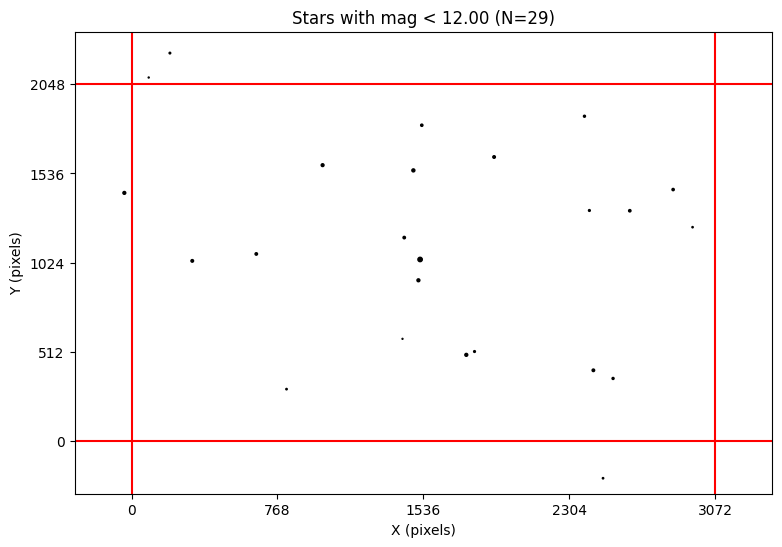

In [2]:

plate_scale = 0.63 
camera_width_pix = 3072 
camera_height_pix = 2048 

center_ra = 279.23 
center_dec = 38.78

theta_deg = 5 
invert = False 
plot_lim_mag = 12 





# Calculate FOV of camera 
term1 = plate_scale/3600*camera_width_pix 
term2 = plate_scale/3600*camera_height_pix 
radius_deg = np.sqrt((term1/2)**2 + (term2/2)**2) 

# Retrieve stars from Hipparcos (bright)
stars_hipparcos = src.retrieve_stars(
    center_ra=center_ra, 
    center_dec=center_dec, 
    radius_deg=radius_deg, 
    catalog="I/239/hip_main", 
)

# Retrive stars from Gaia (dim) 
stars_gaia = src.retrieve_stars(
    center_ra=center_ra, 
    center_dec=center_dec, 
    radius_deg=radius_deg, 
    catalog="I/355/gaiadr3", 
)

# Combine all stars into single dict 
stars = {
    "ra":  np.concatenate([stars_gaia["ra"], stars_hipparcos["ra"]]),
    "dec": np.concatenate([stars_gaia["dec"], stars_hipparcos["dec"]]),
    "mag": np.concatenate([stars_gaia["mag"], stars_hipparcos["mag"]]),
}

# Calculate x, y coordinates of all stars 
stars = src.convert_skycoords_to_pixelcoords(
    stars, 
    center_ra, 
    center_dec, 
    theta_deg, 
    camera_width_pix, 
    camera_height_pix, 
    plate_scale, 
    invert=invert, 
) 

# Create plot 
fig, ax = src.create_plot(
    stars, 
    camera_width_pix, 
    camera_height_pix, 
    plot_lim_mag=plot_lim_mag, 
)


